# Sensor States to Bar Chart.

Onze *smart device* heeft drie verschillende "states".

1. Geen beweging getecteerd (dus geen fietsers).
2. Wel beweging gedetecteerd, maar geen lamp.
3. Wel beweging gedetecteerd en wel lamp.

Dit kunnen wij weergeven in een staafdiagram.
In deze diagram wordt weergegeven hoeveel keer een bepaalde meting uit de sensor komt.

## Stap 1

Data wordt opgehaald van de Adafruit IO API en opgeslagen in een Pandas dataframe.

Als bevestiging wordt een deel van het tabel getoond.

In [9]:
import numpy as np
import pandas as pd

df = pd.read_json("https://io.adafruit.com//api/v2/avinash_student_account/feeds/bike-light-detector.sensor-states/data")

df.head(5)

,id,value,feed_id,feed_key,created_at,created_epoch,expiration
0,0EMR6AN0QF6BJ4E3SM0VWDXFSA,1,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:46+00:00,1610633986,2021-03-15T13:19:46Z
1,0EMR6AM4AZHYZ2BDENVAZTPEQY,1,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:43+00:00,1610633983,2021-03-15T13:19:43Z
2,0EMR6AK7X6CK3D7GMH052D3GGZ,1,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:40+00:00,1610633980,2021-03-15T13:19:40Z
3,0EMR6AJBG0BAA7S7MD23BFNXSB,1,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:37+00:00,1610633977,2021-03-15T13:19:37Z
4,0EMR6AHF11GTK3VAK51NXRY8G6,1,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:34+00:00,1610633974,2021-03-15T13:19:34Z


## Stap 2

De nummers worden omgezet naar strings die het op de staafdiagram duidelijk maken waar het om gaat.

Als bevestiging worden de eerste 5 regels nog een keer opgehaald.

In [10]:
df["value"] = df["value"].map({1: "Geen fietser herkend", 2: "Fietser herkend zonder licht", 3: "Fietser herkend met licht"})

df.head(5)

,id,value,feed_id,feed_key,created_at,created_epoch,expiration
0,0EMR6AN0QF6BJ4E3SM0VWDXFSA,Geen fietser herkend,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:46+00:00,1610633986,2021-03-15T13:19:46Z
1,0EMR6AM4AZHYZ2BDENVAZTPEQY,Geen fietser herkend,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:43+00:00,1610633983,2021-03-15T13:19:43Z
2,0EMR6AK7X6CK3D7GMH052D3GGZ,Geen fietser herkend,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:40+00:00,1610633980,2021-03-15T13:19:40Z
3,0EMR6AJBG0BAA7S7MD23BFNXSB,Geen fietser herkend,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:37+00:00,1610633977,2021-03-15T13:19:37Z
4,0EMR6AHF11GTK3VAK51NXRY8G6,Geen fietser herkend,1532824,bike-light-detector.sensor-states,2021-01-14 14:19:34+00:00,1610633974,2021-03-15T13:19:34Z


## Stap 3

Er wordt gekeken hoe vaak bepaalde waardes van "value" voorkomen. 
Vervolgens wordt dit in een bar chart weergegeven.

<AxesSubplot:>

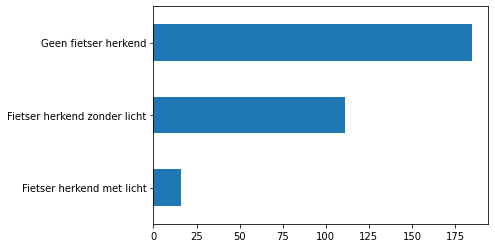

In [11]:
df["value"].value_counts().sort_values().plot(kind = 'barh')